##### 1. Load and Prepare Libraries
Along with loading libraries, the code is ensuring that the GPU is used to train the deep learning models to improve efficiency.

In [1]:
import os
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import(
    LabelEncoder,
    StandardScaler
)
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import json
import sys, re, threading
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import math
import optuna
from optuna.exceptions import TrialPruned
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Layer, Embedding,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Add
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# -----------------------------------------------------------------------------
# Silence harmless low-level C++/CUDA/XLA messages that TensorFlow prints straight
# to file descriptor 2, which TF_CPP_MIN_LOG_LEVEL alone does not stop. Examples:
#   "Skipping the delay kernel, measurement accuracy will be reduced"
#   "'+ptx85' is not a recognized feature for this target (ignoring feature)"
#   "could not open file to read NUMA node ... built without NUMA support"
# A background thread drops these known lines while letting real training output
# (stdout) and genuine errors through. Installed once per kernel session.
# -----------------------------------------------------------------------------
import sys, re, threading

if not globals().get("_STDERR_FILTER_INSTALLED"):
    _NOISE = re.compile(
        r"^[IWEF]\d{4} "                                  # absl logs: I0000/W0000/E0000 ...
        r"|^\d{4}-\d\d-\d\d \d\d:\d\d:\d\d\.\d+: [IWEF] "  # absl logs: 2026-..-..: I/W/E ...
        r"|recognized feature for this target"            # LLVM "+ptxNN" PTX feature notice
        r"|ignoring feature"
        r"|NUMA support"                                  # NUMA-node warnings
        r"|All log messages before absl"
        r"|oneDNN custom operations"
        r"|different numerical results due to"
        r"|TensorFlow binary is optimized"
        r"|To enable the following instructions"
    )
    _orig_err_fd = os.dup(2)
    _pipe_r, _pipe_w = os.pipe()
    os.dup2(_pipe_w, 2)
    os.close(_pipe_w)

    def _filter_stderr(reader_fd=_pipe_r, out_fd=_orig_err_fd, pattern=_NOISE):
        with os.fdopen(reader_fd, "r", errors="replace") as reader:
            for line in reader:
                if not pattern.search(line):
                    os.write(out_fd, line.encode(errors="replace"))

    threading.Thread(target=_filter_stderr, daemon=True).start()
    _STDERR_FILTER_INSTALLED = True

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"TensorFlow {tf.__version__} - GPU(s) found: {[g.name for g in gpus]}")
else:
    print(f"TensorFlow {tf.__version__} - no GPU found, running on CPU.")


2026-08-09 16:52:59.025824: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-09 16:52:59.038071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-09 16:52:59.051929: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-09 16:52:59.056404: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-09 16:52:59.067728: I tensorflow/core/platform/cpu_feature_guar

TensorFlow 2.17.0 - GPU(s) found: ['/physical_device:GPU:0']


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### 2. Load and Add Target Columns
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# dictionary for value insertion for target column
# Keys are matched against file names, so keep these specific enough to avoid overlap.
targets = {
    "PAO1": "0:1 | Staph : PAO",
    "STAPH": "1:0 | Staph : PAO",
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def find_csv_files(data_path):
    if not os.path.isdir(data_path):
        raise FileNotFoundError(f"Data folder not found: {data_path}")

    csv_files = []
    for root, dirs, files in os.walk(data_path):
        dirs[:] = sorted(d for d in dirs if not d.startswith("."))
        for file_name in sorted(files):
            if file_name.endswith(".csv"):
                csv_files.append(os.path.join(root, file_name))

    return sorted(csv_files)

def read_all_csvs_to_df(data_path):
    dataframes = []

    file_list = find_csv_files(data_path)
    if not file_list:
        raise ValueError(f"No CSV files found in: {data_path}")

    for i, file_path in enumerate(file_list):
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path, header=None)

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key.lower() in file_name.lower()), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        labeled_df = df.copy()
        labeled_df["target"] = target_value
        dataframes.append(labeled_df)

    # Some added files have a different number of feature columns. Keep only columns
    # shared by all files so the Transformer never receives NaNs from column misalignment.
    combined_df = pd.concat(dataframes, ignore_index=True, join="inner").copy()

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    target_map = {
        str(original): int(encoded)
        for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
    }

    json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
    with open(json_path, "w") as f:
        json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
data_path = os.path.join("..", "data", "mixed_ratio") #only mixed ratio data
df = read_all_csvs_to_df(data_path)

##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
def label_data(dataframe):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    feature_map = dict(zip(feature_labels, feature_values))
    json_path = os.path.join(os.getcwd(), "feature_map.json")
    with open(json_path, "w") as f:
        json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df

clean_df = label_data(df)

##### 4. Splitting for Transformer
In this cell, the data is being split for an 80-20 training and testing split.

In [4]:
# -----------------------------
# Prepare features and labels
# -----------------------------
if "target_encoded" not in clean_df.columns:
    raise ValueError("clean_df must contain a 'target_encoded' column.")

# X = all feature columns, y = encoded class labels
X_df = clean_df.drop(columns=["target_encoded"]).astype(np.float32)
feature_columns = X_df.columns
X = X_df.to_numpy(dtype=np.float32)
y = clean_df["target_encoded"].astype(int).values

if X.ndim != 2:
    raise ValueError(f"Expected X to be 2D before scaling, got shape {X.shape}")
if np.isnan(X).any():
    raise ValueError("X contains NaN values. Check CSV column alignment before training.")

# Number of classes
n_classes = len(np.unique(y))
print("Number of classes:", n_classes)
print("X shape before scaling:", X.shape)

# -----------------------------
# Standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns, index=X_df.index)

# -----------------------------
# One-hot encode labels
# -----------------------------
y_cat = to_categorical(y, num_classes=n_classes).astype(np.float32)


def add_white_noise_to_features(
    X: pd.DataFrame,
    noise_level: float = 0.05,
    random_state: int = 42,
    relative: bool = True
) -> pd.DataFrame:
    """
    Create a noisy copy of spectral feature rows by adding Gaussian white noise.

    Parameters:
        X (pd.DataFrame): Feature dataframe only (no target column).
        noise_level (float): Noise strength.
            If relative=True, this is multiplied by each row's std.
            If relative=False, this is used as the std of the noise directly.
        random_state (int): Seed for reproducibility.
        relative (bool): If True, scale noise by each row's spectral std.
                         If False, use fixed std for all features.

    Returns:
        X_noisy (pd.DataFrame): Noisy copy of X with same shape/index/columns.
    """
    rng = np.random.default_rng(random_state)
    X_values = X.to_numpy(dtype=float)

    if relative:
        row_std = X_values.std(axis=1, keepdims=True)
        row_std = np.where(row_std == 0, 1e-8, row_std)
        noise = rng.normal(loc=0.0, scale=noise_level * row_std, size=X_values.shape)
    else:
        noise = rng.normal(loc=0.0, scale=noise_level, size=X_values.shape)

    X_noisy = X_values + noise

    return pd.DataFrame(X_noisy, columns=X.columns, index=X.index)


# -----------------------------
# Train-test split
# -----------------------------
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_scaled_df,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y   # stratify with integer labels, not one-hot labels
)

# Duplicate the held-out 0.2 test dataframe and add white noise to evaluate
# robustness after training only on clean spectra.
X_test_noisy_df = add_white_noise_to_features(
    X_test_df,
    noise_level=0.05,
    random_state=42,
    relative=True
)

# -----------------------------
# Reshape for Transformer
# Transformer expects: (samples, timesteps, channels)
# -----------------------------
X_train = X_train_df.to_numpy(dtype=np.float32)[..., np.newaxis]
X_test = X_test_df.to_numpy(dtype=np.float32)[..., np.newaxis]
X_test_noisy = X_test_noisy_df.to_numpy(dtype=np.float32)[..., np.newaxis]
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

if X_train.ndim != 3 or X_test.ndim != 3 or X_test_noisy.ndim != 3:
    raise ValueError(
        f"Transformer input must be 3D. Got X_train {X_train.shape}, "
        f"X_test {X_test.shape}, X_test_noisy {X_test_noisy.shape}"
    )
if X_train.shape[1:] != (X_scaled.shape[1], 1) or X_test.shape[1:] != (X_scaled.shape[1], 1):
    raise ValueError(f"Unexpected Transformer shape. Got X_train {X_train.shape}, X_test {X_test.shape}")
if X_test_noisy.shape != X_test.shape:
    raise ValueError(f"Noisy test shape must match clean test shape. Got {X_test_noisy.shape} vs {X_test.shape}")
if y_train.shape[1] != n_classes or y_test.shape[1] != n_classes:
    raise ValueError(f"One-hot labels must have {n_classes} columns. Got y_train {y_train.shape}, y_test {y_test.shape}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_test_noisy shape:", X_test_noisy.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train dtype:", X_train.dtype)
print("X_test_noisy dtype:", X_test_noisy.dtype)
print("y_train dtype:", y_train.dtype)

Number of classes: 5
X shape before scaling: (61754, 388)


X_train shape: (49403, 388, 1)
X_test shape: (12351, 388, 1)
X_test_noisy shape: (12351, 388, 1)
y_train shape: (49403, 5)
y_test shape: (12351, 5)
X_train dtype: float32
X_test_noisy dtype: float32
y_train dtype: float32


##### 5. Transformer Architecture
In this cell, the actual model architecture is being built. Before training and running the model, layers and parameteres are being defined.

In [5]:
# -----------------------------
# Hyperparameter-search settings
# -----------------------------
RUN_OPTUNA_SEARCH = False  # False = train on BEST_HYPERPARAMETERS below, no search
OPTUNA_N_TRIALS = 5      # how many combinations to try (only when RUN_OPTUNA_SEARCH)
OPTUNA_TIMEOUT = None     # optional wall-clock limit in seconds (None = no limit)
OPTUNA_SEED = 42
MAX_EPOCHS = 50           # upper bound per run; early stopping ends most runs sooner

# The hyperparameters this notebook trains on: the winning combination from the
# Optuna search that was already run (also recorded in best_hyperparameters.txt).
BEST_HYPERPARAMETERS = {
    "patch_size": 8,
    "d_model": 32,
    "num_heads": 4,
    "ff_dim": 256,
    "num_transformer_blocks": 4,
    "mlp_units": 32,
    "dropout": 0.2216968971838151,
    "l2_strength": 0.00037520558551242813,
    "learning_rate": 0.0007309539835912913,
    "batch_size": 128,
    "epochs": 28,
}


def suggest_transformer_params(trial):
    """Sample one hyperparameter combination from the search space."""
    return {
        # patch_size = how many neighbouring wavenumbers are grouped into one token,
        # which sets the sequence length the attention layers operate over.
        "patch_size": trial.suggest_categorical("patch_size", [4, 8, 16]),
        "d_model": trial.suggest_categorical("d_model", [32, 64, 128]),
        "num_heads": trial.suggest_categorical("num_heads", [2, 4, 8]),
        "ff_dim": trial.suggest_categorical("ff_dim", [64, 128, 256]),
        "num_transformer_blocks": trial.suggest_int("num_transformer_blocks", 1, 4),
        "mlp_units": trial.suggest_categorical("mlp_units", [32, 64, 128]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "l2_strength": trial.suggest_float("l2_strength", 1e-5, 1e-2, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "epochs": MAX_EPOCHS,
    }


def prepare_transformer_params(params):
    """Derive builder-only values from the sampled hyperparameters."""
    params = params.copy()
    # d_model and num_heads are drawn from divisible sets, so this stays an integer.
    params["key_dim"] = max(params["d_model"] // params["num_heads"], 1)
    return params


class StopOnValidationLossIncrease(Callback):
    """Stop as soon as validation loss rises above the best value seen so far."""

    def __init__(self, monitor="val_loss", min_delta=0.0):
        super().__init__()
        self.monitor = monitor
        self.min_delta = min_delta
        self.best = float("inf")
        self.best_epoch = 0
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if current < self.best - self.min_delta:
            self.best = current
            self.best_epoch = epoch + 1
            return

        if current > self.best + self.min_delta:
            self.stopped_epoch = epoch + 1
            print(
                f"Overfitting detected at epoch {self.stopped_epoch}: "
                f"{self.monitor}={current:.4f} > best_{self.monitor}={self.best:.4f} "
                f"from epoch {self.best_epoch}. Stopping training."
            )
            self.model.stop_training = True


class OptunaPruningCallback(Callback):
    """Report validation accuracy to Optuna each epoch and prune unpromising trials."""

    def __init__(self, trial, monitor="val_accuracy"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(value, step=epoch)
        if self.trial.should_prune():
            raise TrialPruned()


class SpectralPatchEmbedding(Layer):
    """Tokenize a 1D spectrum for the transformer encoder.

    The spectrum arrives as (seq_len, 1). It is split into fixed-size patches of
    neighbouring wavenumbers, each patch is linearly projected to d_model, and a
    learnable positional embedding is added. The projection is a plain Dense layer
    (no convolution), so the network below is a pure transformer encoder.
    """

    def __init__(self, patch_size, d_model, l2_strength, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.d_model = d_model
        self.l2_strength = l2_strength
        self.projection = Dense(d_model, kernel_regularizer=l2(l2_strength))

    def build(self, input_shape):
        seq_len = int(input_shape[1])
        self.n_patches = math.ceil(seq_len / self.patch_size)
        # Pad the wavenumber axis up to a whole number of patches.
        self.pad_len = self.n_patches * self.patch_size - seq_len
        self.position_embedding = Embedding(
            input_dim=self.n_patches, output_dim=self.d_model
        )
        super().build(input_shape)

    def call(self, inputs):
        x = inputs
        if self.pad_len > 0:
            x = tf.pad(x, [[0, 0], [0, self.pad_len], [0, 0]])
        # (batch, seq_len, 1) -> (batch, n_patches, patch_size) -> (batch, n_patches, d_model)
        x = tf.reshape(x, (tf.shape(x)[0], self.n_patches, self.patch_size))
        x = self.projection(x)
        positions = tf.range(start=0, limit=self.n_patches, delta=1)
        return x + self.position_embedding(positions)


def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout, l2_strength):
    """One pre-norm transformer encoder block: multi-head self-attention and a
    position-wise feed-forward network, each wrapped in a residual connection."""
    # --- Multi-head self-attention sublayer ---
    attn_input = LayerNormalization(epsilon=1e-6)(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout
    )(attn_input, attn_input)
    x = Add()([x, attn_output])

    # --- Feed-forward sublayer ---
    ff_input = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation="relu", kernel_regularizer=l2(l2_strength))(ff_input)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1], kernel_regularizer=l2(l2_strength))(ff)
    return Add()([x, ff])


def build_transformer_model(params):
    seq_len = X_train.shape[1]

    inputs = Input(shape=(seq_len, 1))

    # Tokenize the spectrum into patch embeddings + positional information.
    x = SpectralPatchEmbedding(
        patch_size=params["patch_size"],
        d_model=params["d_model"],
        l2_strength=params["l2_strength"],
    )(inputs)
    x = Dropout(params["dropout"])(x)

    # Stack of transformer encoder blocks.
    for _ in range(params["num_transformer_blocks"]):
        x = transformer_encoder_block(
            x,
            num_heads=params["num_heads"],
            key_dim=params["key_dim"],
            ff_dim=params["ff_dim"],
            dropout=params["dropout"],
            l2_strength=params["l2_strength"],
        )

    # Pool over the token axis, then a small MLP classification head.
    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(params["dropout"])(x)
    x = Dense(
        params["mlp_units"], activation="relu", kernel_regularizer=l2(params["l2_strength"])
    )(x)
    x = Dropout(params["dropout"])(x)
    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
        jit_compile=False
    )
    return model


def objective(trial):
    """Train one candidate model and return its best validation accuracy.

    EarlyStopping with restore_best_weights and Optuna's median pruner both guard
    against overfitting: weak or overfitting trials are stopped/pruned early.
    """
    params = prepare_transformer_params(suggest_transformer_params(trial))
    K.clear_session()
    model = build_transformer_model(params)

    trial_early_stop = EarlyStopping(
        monitor="val_loss", patience=3, min_delta=0.0,
        restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[trial_early_stop, OptunaPruningCallback(trial, "val_accuracy")],
        verbose=0,
    )
    return max(history.history["val_accuracy"])


# -----------------------------
# Choose the hyperparameters to train on
# -----------------------------
# Default path: reuse BEST_HYPERPARAMETERS. A 5-trial TPE search is not reproducible
# run to run, so searching again would silently change the model being compared --
# the paired Cochran's Q / McNemar tests need every notebook pinned to fixed settings.
# Flip RUN_OPTUNA_SEARCH to True to search again and overwrite best_hyperparameters.txt.
if RUN_OPTUNA_SEARCH:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=4)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT)

    print(f"Completed {len(study.trials)} trials.")
    print(f"Best validation accuracy: {study.best_value:.4f}")
    print("Best hyperparameters:", study.best_params)

    # Save the best hyperparameters for reference.
    with open(os.path.join(os.getcwd(), "best_hyperparameters.txt"), "w") as f:
        f.write(f"Best validation accuracy: {study.best_value:.4f}\n")
        for key, value in study.best_params.items():
            f.write(f"{key}: {value}\n")

    chosen_params = suggest_transformer_params(optuna.trial.FixedTrial(study.best_params))
else:
    print("Skipping the Optuna search; training on BEST_HYPERPARAMETERS.")
    chosen_params = BEST_HYPERPARAMETERS.copy()

# -----------------------------
# Build the final model from the chosen hyperparameters
# -----------------------------
best_params = prepare_transformer_params(chosen_params)
best_batch_size = best_params["batch_size"]
best_epochs = best_params["epochs"]

print("Using hyperparameters:", chosen_params)
print("Epochs:", best_epochs)

K.clear_session()
model = build_transformer_model(best_params)
model.summary()

overfitting_stop = StopOnValidationLossIncrease(monitor="val_loss", min_delta=0.0)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.0,
    restore_best_weights=True,
    verbose=1
)

Skipping the Optuna search; training on BEST_HYPERPARAMETERS.
Using hyperparameters: {'patch_size': 8, 'd_model': 32, 'num_heads': 4, 'ff_dim': 256, 'num_transformer_blocks': 4, 'mlp_units': 32, 'dropout': 0.2216968971838151, 'l2_strength': 0.00037520558551242813, 'learning_rate': 0.0007309539835912913, 'batch_size': 128, 'epochs': 28}
Epochs: 28


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 388, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_patch_emb… │ (None, 49, 32)    │      1,856 │ input_layer[0][0] │
│ (SpectralPatchEmbe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 32)    │          0 │ spectral_patch_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 32)    │         64 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 32)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 256)   │      8,448 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 32)    │      8,224 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 32)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 256)   │      8,448 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 256)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 32)    │      8,224 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 49, 32)    │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_4[0][0]   

 Total params: 87,237 (340.77 KB)

 Trainable params: 87,237 (340.77 KB)

 Non-trainable params: 0 (0.00 B)

##### 6. Training

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=best_epochs,
    batch_size=best_batch_size,
    callbacks=[overfitting_stop, early_stop],
    verbose=1
)

Epoch 1/28


  1/309 ━━━━━━━━━━━━━━━━━━━━ 43:53 9s/step - accuracy: 0.1484 - loss: 1.9430

  3/309 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.1888 - loss: 1.8775

  5/309 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.2180 - loss: 1.8308

  7/309 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2377 - loss: 1.8025

...

305/309 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9032 - loss: 0.3890

307/309 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9032 - loss: 0.3890

309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9032 - loss: 0.3889

Overfitting detected at epoch 6: val_loss=0.3498 > best_val_loss=0.3410 from epoch 5. Stopping training.
309/309 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9033 - loss: 0.3889 - val_accuracy: 0.9155 - val_loss: 0.3498


Restoring model weights from the end of the best epoch: 5.


##### 6b. Learning Curve (Training vs Validation)

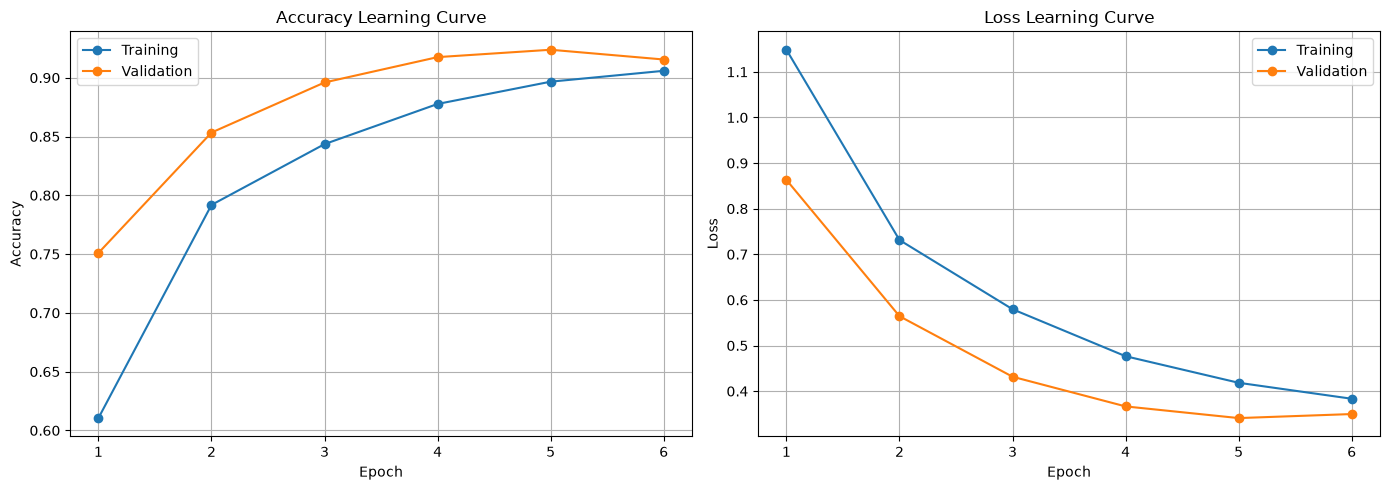

Final training accuracy:   0.9059
Final validation accuracy: 0.9155
Train/val accuracy gap:    -0.0096 (large positive gap suggests overfitting)


In [7]:
# -----------------------------
# Learning curves: training vs validation accuracy and loss per epoch.
# A widening gap between the training and validation curves indicates overfitting.
# -----------------------------
hist = history.history
epochs_ran = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))

ax_acc.plot(epochs_ran, hist["accuracy"], marker="o", label="Training")
ax_acc.plot(epochs_ran, hist["val_accuracy"], marker="o", label="Validation")
ax_acc.set_title("Accuracy Learning Curve")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(True)

ax_loss.plot(epochs_ran, hist["loss"], marker="o", label="Training")
ax_loss.plot(epochs_ran, hist["val_loss"], marker="o", label="Validation")
ax_loss.set_title("Loss Learning Curve")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()
ax_loss.grid(True)

plt.tight_layout()
plt.show()

final_gap = hist["accuracy"][-1] - hist["val_accuracy"][-1]
print(f"Final training accuracy:   {hist['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {hist['val_accuracy'][-1]:.4f}")
print(f"Train/val accuracy gap:    {final_gap:.4f} (large positive gap suggests overfitting)")

##### 7. Performance Visualization

  1/386 ━━━━━━━━━━━━━━━━━━━━ 1:46 277ms/step

 23/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step    

 45/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 67/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 89/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

342/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

367/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

386/386 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


Clean 0.2 Test Set accuracy: 0.9198


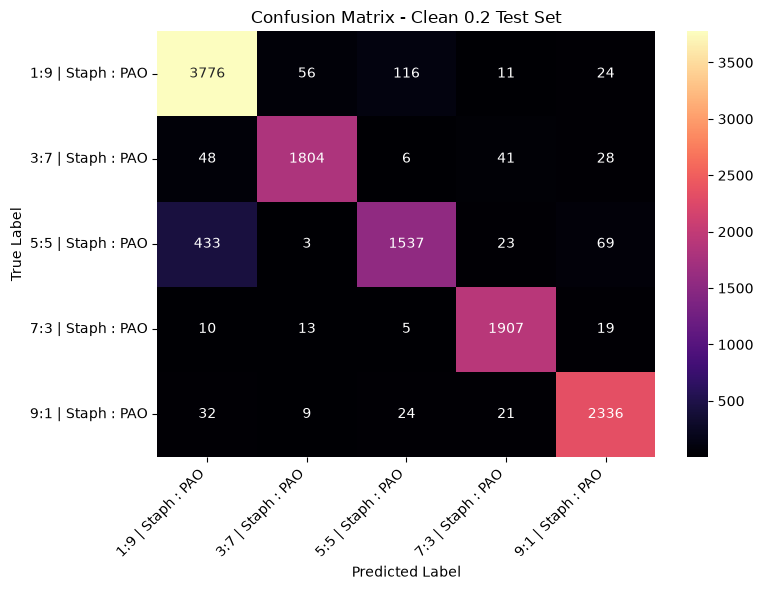

Classification Report - Clean 0.2 Test Set:

                   precision    recall  f1-score   support

1:9 | Staph : PAO       0.88      0.95      0.91      3983
3:7 | Staph : PAO       0.96      0.94      0.95      1927
5:5 | Staph : PAO       0.91      0.74      0.82      2065
7:3 | Staph : PAO       0.95      0.98      0.96      1954
9:1 | Staph : PAO       0.94      0.96      0.95      2422

         accuracy                           0.92     12351
        macro avg       0.93      0.91      0.92     12351
     weighted avg       0.92      0.92      0.92     12351



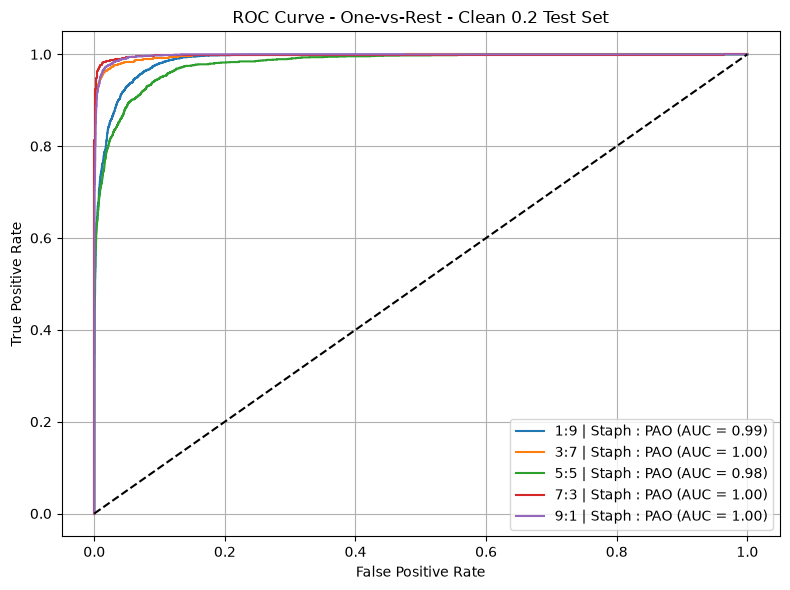

  1/386 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

 21/386 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 43/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 65/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 90/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

...

320/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

343/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

366/386 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

386/386 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Noisy 0.2 Test Set accuracy: 0.9192


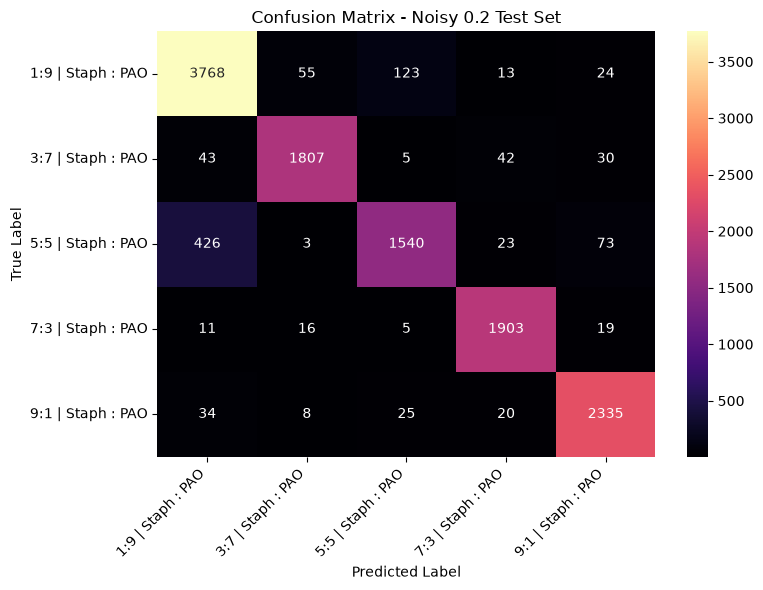

Classification Report - Noisy 0.2 Test Set:

                   precision    recall  f1-score   support

1:9 | Staph : PAO       0.88      0.95      0.91      3983
3:7 | Staph : PAO       0.96      0.94      0.95      1927
5:5 | Staph : PAO       0.91      0.75      0.82      2065
7:3 | Staph : PAO       0.95      0.97      0.96      1954
9:1 | Staph : PAO       0.94      0.96      0.95      2422

         accuracy                           0.92     12351
        macro avg       0.93      0.91      0.92     12351
     weighted avg       0.92      0.92      0.92     12351



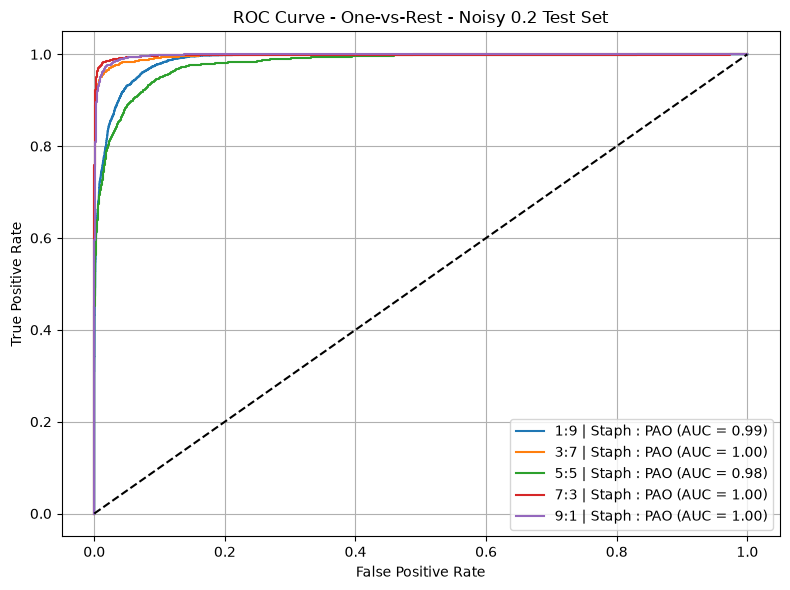

Accuracy comparison:
Clean 0.2 test accuracy: 0.9198
Noisy 0.2 test accuracy: 0.9192
Accuracy drop from white noise: 0.0006


In [8]:
# -----------------------------
# Load readable class names
# -----------------------------
# This was created earlier in your preprocessing code
json_path = os.path.join(os.getcwd(), "target_encoding_map.json")

with open(json_path, "r") as f:
    target_map = json.load(f)

# target_map looks like:
# {
#   "1:9 | Staph : PAO": 0,
#   "3:7 | Staph : PAO": 1,
#   ...
# }

# Reverse it so encoded integer -> original class label
reverse_target_map = {int(v): k for k, v in target_map.items()}

# Make labels in the correct numeric order
labels = [reverse_target_map[i] for i in range(n_classes)]
class_ids = list(range(n_classes))
y_true = np.argmax(y_test, axis=1)
y_true_bin = label_binarize(y_true, classes=class_ids)
if y_true_bin.shape[1] == 1:
    # Binary case (2 classes): label_binarize returns a single column, but the
    # softmax output and the per-class ROC loop expect one column per class.
    y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])


def evaluate_transformer_test_set(X_eval, y_true, dataset_name, show_roc=True):
    # -----------------------------
    # Predict on test set
    # -----------------------------
    y_pred_probs = model.predict(X_eval)
    y_pred = np.argmax(y_pred_probs, axis=1)
    accuracy = accuracy_score(y_true, y_pred)

    print(f"{dataset_name} accuracy: {accuracy:.4f}")

    # -----------------------------
    # Confusion matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='magma',
        cbar=True,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Classification report
    # -----------------------------
    print(f"Classification Report - {dataset_name}:\n")
    print(classification_report(y_true, y_pred, target_names=labels))

    # -----------------------------
    # ROC Curve (One-vs-Rest)
    # -----------------------------
    if show_roc:
        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f"ROC Curve - One-vs-Rest - {dataset_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": accuracy,
        "y_pred": y_pred,
        "y_pred_probs": y_pred_probs,
        "confusion_matrix": cm,
    }


clean_results = evaluate_transformer_test_set(X_test, y_true, "Clean 0.2 Test Set")
noisy_results = evaluate_transformer_test_set(X_test_noisy, y_true, "Noisy 0.2 Test Set")

print("Accuracy comparison:")
print(f"Clean 0.2 test accuracy: {clean_results['accuracy']:.4f}")
print(f"Noisy 0.2 test accuracy: {noisy_results['accuracy']:.4f}")
print(f"Accuracy drop from white noise: {clean_results['accuracy'] - noisy_results['accuracy']:.4f}")

##### 7b. Train vs Test Accuracy
This cell reports training accuracy next to the test accuracy so the train/test gap (a quick overfitting check) is visible alongside the accuracy comparison.

In [9]:
# -----------------------------
# Train accuracy vs. test accuracy (overfitting gap)
# -----------------------------
# Adds the model's accuracy on the training set next to the clean/noisy test
# accuracies reported above. A large train/test gap is a sign of overfitting.
train_accuracy = accuracy_score(
    np.argmax(y_train, axis=1),
    np.argmax(model.predict(X_train), axis=1)
)

print("Accuracy comparison (train vs test):")
print(f"Train accuracy:           {train_accuracy:.4f}")
print(f"Clean 0.2 test accuracy:  {clean_results['accuracy']:.4f}")
print(f"Noisy 0.2 test accuracy:  {noisy_results['accuracy']:.4f}")
print(f"Train/clean-test gap:     {train_accuracy - clean_results['accuracy']:.4f}")

   1/1544 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step

  26/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step  

  50/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

  75/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

  99/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

...

1494/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1519/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1541/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Accuracy comparison (train vs test):
Train accuracy:           0.9233
Clean 0.2 test accuracy:  0.9198
Noisy 0.2 test accuracy:  0.9192
Train/clean-test gap:     0.0036


##### Export Predictions for Model Comparison (Cochran's Q + McNemar)
- Writes this model's predictions on the **noisy** 80/20 test set into the shared `model_predictions.csv`, aligned by `sample_id` (the original `clean_df` row index).
- The model is trained on clean spectra only; white noise is added to the held-out test rows alone, so this is the clean-train / noisy-test comparison.
- Run all four notebooks (RF, XGBoost, CNN, Transformer), then run `cochrans_q_analysis.py` on `model_predictions.csv`.

In [10]:
# Export this model's predictions to the shared CSV consumed by cochrans_q_analysis.py.
# Every notebook writes to model_predictions.csv, aligned by sample_id (the original
# clean_df row index), so all four models are compared on the identical NOISY test set:
# the same held-out 20% rows, each perturbed by add_white_noise_to_features with the
# same noise_level=0.05 / random_state=42 / relative=True settings used above.
def export_model_predictions(model_name, sample_ids, y_true_encoded, y_pred_encoded,
                             predictions_csv="model_predictions.csv",
                             label_map_path="target_encoding_map.json"):
    with open(label_map_path) as f:
        label_map = json.load(f)                       # {label_string: encoded_int}
    inv = {int(v): k for k, v in label_map.items()}

    new = pd.DataFrame({
        "sample_id": np.asarray(sample_ids, dtype=int),
        "true_label": [inv[int(v)] for v in np.asarray(y_true_encoded)],
        model_name: [inv[int(v)] for v in np.asarray(y_pred_encoded)],
    }).sort_values("sample_id").reset_index(drop=True)

    if os.path.exists(predictions_csv):
        shared = pd.read_csv(predictions_csv)
        if set(shared["sample_id"]) != set(new["sample_id"]):
            raise ValueError(
                f"{model_name}: sample_ids differ from existing {predictions_csv}. All models "
                "must use the same test split -- delete the CSV and rerun every notebook."
            )
        chk = shared[["sample_id", "true_label"]].merge(
            new[["sample_id", "true_label"]], on="sample_id", suffixes=("_a", "_b"))
        if not (chk["true_label_a"].astype(str) == chk["true_label_b"].astype(str)).all():
            raise ValueError(f"{model_name}: true_label disagrees with existing {predictions_csv}.")
        shared = shared.drop(columns=[model_name], errors="ignore")   # a re-run overwrites just this column
        merged = shared.merge(new[["sample_id", model_name]], on="sample_id", how="left")
    else:
        merged = new

    front = ["sample_id", "true_label"]
    merged = merged[front + [c for c in merged.columns if c not in front]]
    merged = merged.sort_values("sample_id").reset_index(drop=True)
    merged.to_csv(predictions_csv, index=False)
    print(f"[{model_name}] wrote noisy-test predictions for {len(new)} samples -> {predictions_csv}")
    return merged


predictions_df = export_model_predictions(
    "Transformer",
    sample_ids=X_test_df.index.to_numpy(),
    y_true_encoded=y_true,
    y_pred_encoded=noisy_results["y_pred"],
)
predictions_df.head()

[Transformer] wrote noisy-test predictions for 12351 samples -> model_predictions.csv


,sample_id,true_label,CNN,Transformer
0,2,1:9 | Staph : PAO,3:7 | Staph : PAO,1:9 | Staph : PAO
1,9,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO
2,11,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO
3,13,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO
4,16,1:9 | Staph : PAO,1:9 | Staph : PAO,1:9 | Staph : PAO


##### 8. Cross-Validation Accuracy (5-Fold)
This cell does Cross-Validation Accuracy as an overfitting check. 

In [11]:
# -----------------------------------------------------------------------------
# 5-Fold Cross-Validation Accuracy
# -----------------------------------------------------------------------------
# Same cross-validation accuracy report as the RF and XGBoost notebooks, adapted
# for a Keras model. scikit-learn's cross_val_score cannot train a Keras network,
# so the 5 folds are run by hand with StratifiedKFold: each fold rebuilds the
# transformer from the best hyperparameters, trains on the training split, and
# scores accuracy on the held-out split. The StandardScaler is refit inside every
# fold (on training rows only), which is the leak-free way cross_val_score refits
# the RF/XG estimators per fold. Cross-validation uses the clean spectra the model
# trains on; the noisy set is kept separate, matching the clean-train design.

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    # Refit the scaler on this fold's training rows only, then apply to both splits.
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X[train_idx]).astype(np.float32)
    X_val = fold_scaler.transform(X[val_idx]).astype(np.float32)

    # StratifiedKFold returns ascending indices, so shuffle the training fold to keep
    # Keras's validation_split (its last 20%, taken before shuffling) representative.
    rng = np.random.default_rng(42 + fold)
    perm = rng.permutation(X_tr.shape[0])
    X_tr = X_tr[perm][..., np.newaxis]
    y_tr = to_categorical(y[train_idx][perm], num_classes=n_classes).astype(np.float32)

    X_val = X_val[..., np.newaxis]
    y_val = to_categorical(y[val_idx], num_classes=n_classes).astype(np.float32)

    # Rebuild and retrain a fresh model so folds never share weights, using the same
    # callbacks, epoch budget, and batch size as the final model trained above.
    K.clear_session()
    fold_model = build_transformer_model(best_params)
    fold_callbacks = [
        StopOnValidationLossIncrease(monitor="val_loss", min_delta=0.0),
        EarlyStopping(
            monitor="val_loss", patience=3, min_delta=0.0,
            restore_best_weights=True, verbose=0
        ),
    ]
    fold_model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=best_epochs,
        batch_size=best_batch_size,
        callbacks=fold_callbacks,
        verbose=0
    )

    fold_acc = fold_model.evaluate(X_val, y_val, verbose=0)[1]
    cv_scores.append(fold_acc)
    print(f"Fold {fold}/{N_SPLITS} accuracy: {fold_acc:.4f}")

cv_scores = np.array(cv_scores)

print("\nCross-Validation Accuracy Scores:", np.round(cv_scores, 4))
print("CV Mean Accuracy:", round(cv_scores.mean(), 4))
print("CV Std Dev:", round(cv_scores.std(), 4))

Overfitting detected at epoch 7: val_loss=0.3376 > best_val_loss=0.3208 from epoch 6. Stopping training.


Fold 1/5 accuracy: 0.9210


Overfitting detected at epoch 10: val_loss=0.2959 > best_val_loss=0.2908 from epoch 9. Stopping training.


Fold 2/5 accuracy: 0.9217


Overfitting detected at epoch 14: val_loss=0.2204 > best_val_loss=0.2199 from epoch 13. Stopping training.


Fold 3/5 accuracy: 0.9377


Overfitting detected at epoch 5: val_loss=0.3734 > best_val_loss=0.3510 from epoch 4. Stopping training.


Fold 4/5 accuracy: 0.9200


Overfitting detected at epoch 7: val_loss=0.3445 > best_val_loss=0.3254 from epoch 6. Stopping training.


Fold 5/5 accuracy: 0.9243

Cross-Validation Accuracy Scores: [0.921  0.9217 0.9377 0.92   0.9243]
CV Mean Accuracy: 0.9249
CV Std Dev: 0.0065
